## Что здесь важно понимать про метрику

При девяти классах и в среднем 1.06 тега на ролик матрица меток почти на 88%
состоит из нулей. Модель, которая всегда предсказывает «нет тега», получает по
доле верных ячеек 0.883, не научившись ничему.

Обученная модель даёт по той же метрике 0.927 — то есть весь результат работы
укладывается в 4 процентных пункта над константой. Поэтому основная метрика
здесь — **F1-macro**, а accuracy приводится только рядом с константным
предсказателем, чтобы разрыв был виден.

Итог: F1-macro 0.689, F1-micro 0.721, subset accuracy 0.586 на отложенной
выборке. На Kaggle — 0.911 public, 0.885 private.

## Окружение и константы


In [1]:
import os
import json

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, classification_report,
    average_precision_score,
)
from tqdm import tqdm

SEED = 42
NUM_FRAMES = 5
BATCH_SIZE = 8
EPOCHS = 15
IMG_SIZE = 224

CLASSES = ["animal", "car", "cloud", "dance", "fire", "flower", "food", "sunset", "water"]

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda

In [2]:
from google.colab import drive
drive.mount("/content/drive")

ROOT = "/content/drive/MyDrive/what-on-the-video"
TRAIN_CSV = f"{ROOT}/train.csv"
SAMPLE_SUBMIT = f"{ROOT}/sample_submit.csv"
TRAIN_VIDEO_DIR = f"{ROOT}/train"
TEST_VIDEO_DIR = f"{ROOT}/test"

FRAME_CACHE = "/content/frames"  # локальный диск, не Drive

train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(SAMPLE_SUBMIT)
if "file_name" in test_df.columns:
    test_df = test_df.rename(columns={"file_name": "path"})

print(f"train: {len(train_df)}, test: {len(test_df)}")
train_df.head()

train: 290, test: 435

,path,labels
0,port_before_sunrise_preview.mp4,sunset
1,Louisiana speeding boat on Mississippi River_p...,cloud
2,170509A_Vietnam_03_preview.mp4,water
3,Croatia water on rocks at high tide pan_previe...,water
4,Arizona zoom on sunset mountain_preview.mp4,sunset


## Разбор разметки

Метки лежат строкой свободного формата. Наивный вариант — искать имя класса как
подстроку — ломается на пересечениях: `car` находится внутри `carpet`, `water`
внутри `waterfall`, а `flower` содержит `flow`. Поэтому режу строку на слова и
сравниваю целиком, дополнительно раскрывая частые русские варианты написания.


In [3]:
import re

SYNONYMS = {
    "animal": {"animal", "animals", "животное", "животные", "зверь"},
    "car":    {"car", "cars", "auto", "машина", "машины", "автомобиль"},
    "cloud":  {"cloud", "clouds", "облако", "облака"},
    "dance":  {"dance", "dancing", "dancer", "танец", "танцы"},
    "fire":   {"fire", "flame", "огонь", "пламя", "костер"},
    "flower": {"flower", "flowers", "цветок", "цветы"},
    "food":   {"food", "еда", "блюдо"},
    "sunset": {"sunset", "sunrise", "закат", "рассвет"},
    "water":  {"water", "sea", "ocean", "river", "вода", "море", "океан", "река"},
}

TOKEN_RE = re.compile(r"[a-zA-Zа-яА-ЯёЁ]+")


def parse_labels(text):
    tokens = {t.lower().replace("ё", "е") for t in TOKEN_RE.findall(str(text))}
    return [c for c in CLASSES if tokens & SYNONYMS[c]]


train_df["tags"] = train_df["labels"].fillna("").apply(parse_labels)

Y = np.zeros((len(train_df), len(CLASSES)), dtype=np.float32)
for i, tags in enumerate(train_df["tags"]):
    for t in tags:
        Y[i, CLASSES.index(t)] = 1.0

print("Роликов без единого тега:", int((Y.sum(axis=1) == 0).sum()))
print("Среднее число тегов на ролик:", round(float(Y.sum(axis=1).mean()), 2))
print()
print(pd.Series(Y.sum(axis=0), index=CLASSES, dtype=int)
        .sort_values(ascending=False).to_string())

Роликов без единого тега: 0
Среднее число тегов на ролик: 1.06

water     81
cloud     56
sunset    33
car       33
food      30
flower    29
animal    21
dance     17
fire       6

Классы несбалансированы сильно: `water` встречается 81 раз, `fire` — 6.
Это придётся учитывать при интерпретации F1: у редких классов на валидацию
попадёт один-два примера, и их метрики будут шумными независимо от качества
модели.

## Валидация

В исходной постановке отложенной выборки нет — есть только train и тест без
разметки. Без валидации нельзя ни выбрать порог, ни понять, когда останавливать
обучение, поэтому отрезаю 20% train.

Стратифицировать multi-label напрямую нельзя, поэтому стратифицирую по
комбинации тегов, схлопывая редкие комбинации (встречающиеся один раз) в общую
корзину — иначе `train_test_split` не сможет разложить их по обеим частям.


In [4]:
def safe_stratify(labels, min_count=2):
    """Схлопывает редкие группы, пока каждая не наберёт min_count.

    Одиночную корзину 'rare' приклеиваем к самой частой группе: иначе
    train_test_split не сможет разложить её по обеим частям.
    """
    labels = pd.Series(labels).astype(str)
    while True:
        counts = labels.value_counts()
        rare = counts[counts < min_count].index
        if len(rare) == 0:
            return labels
        if len(rare) == 1 and rare[0] == "rare":
            labels = labels.replace("rare", counts.idxmax())
            continue
        labels = labels.where(~labels.isin(rare), "rare")


combo = train_df["tags"].apply(lambda tags: "|".join(tags) if tags else "none")
strat = safe_stratify(combo)

print(f"Уникальных комбинаций тегов: {combo.nunique()}, "
      f"после схлопывания редких: {strat.nunique()}")

train_idx, val_idx = train_test_split(
    np.arange(len(train_df)), test_size=0.2, random_state=SEED, stratify=strat
)

print(f"train: {len(train_idx)}, val: {len(val_idx)}")
print()
print(pd.DataFrame({
    "train": Y[train_idx].sum(axis=0).astype(int),
    "val": Y[val_idx].sum(axis=0).astype(int),
}, index=CLASSES).to_string())

Уникальных комбинаций тегов: 12, после схлопывания редких: 11
train: 232, val: 58

        train  val
animal     17    4
car        26    7
cloud      45   11
dance      14    3
fire        5    1
flower     23    6
food       24    6
sunset     26    7
water      65   16

## Кадры

Первая версия читала видео с Google Drive прямо в `__getitem__`. Первая эпоха
занимала 6.5 минут против 40 секунд у последующих — всё время уходило на сетевое
чтение, а не на вычисления.

Поэтому кадры извлекаются один раз и складываются на локальный диск, дальше
DataLoader читает уже готовые jpg. Заодно это делает видимыми повреждённые файлы:
раньше нечитаемый ролик молча превращался в тензор из нулей и участвовал в
обучении как валидный пример.


In [5]:
def extract_frames(video_path, out_dir, num_frames=NUM_FRAMES):
    """Достаёт num_frames равномерно распределённых кадров. Возвращает False,
    если файл не читается — такие ролики отсекаются, а не молча заменяются нулями."""
    os.makedirs(out_dir, exist_ok=True)
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        return False

    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total < 1:
        cap.release()
        return False

    indices = np.linspace(0, total - 1, num_frames, dtype=int)
    ok_count = 0
    for k, idx in enumerate(indices):
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret:
            continue
        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        cv2.imwrite(os.path.join(out_dir, f"{k:02d}.jpg"), frame)
        ok_count += 1

    cap.release()
    return ok_count == num_frames


def cache_split(df, video_dir, subdir):
    broken = []
    for name in tqdm(df["path"], desc=subdir):
        out_dir = os.path.join(FRAME_CACHE, subdir, os.path.splitext(name)[0])
        if os.path.isdir(out_dir) and len(os.listdir(out_dir)) == NUM_FRAMES:
            continue
        if not extract_frames(os.path.join(video_dir, name), out_dir):
            broken.append(name)
    return broken


broken_train = cache_split(train_df, TRAIN_VIDEO_DIR, "train")
broken_test = cache_split(test_df, TEST_VIDEO_DIR, "test")

print("Не прочитались в train:", len(broken_train))
print("Не прочитались в test: ", len(broken_test))

test: 100%|██████████| 435/435 [08:32<00:00,  1.18s/it]

Не прочитались в train: 0
Не прочитались в test:  1

Один тестовый ролик не читается — тот самый файл, который в первой версии молча
превращался в тензор из нулей и участвовал в предсказании как валидный. Теперь
он виден и посчитан.

Извлечение заняло 14 минут на 725 роликов, дальше DataLoader читает готовые jpg
с локального диска.


In [6]:
class FrameDataset(Dataset):
    def __init__(self, df, indices, subdir, transform, targets=None):
        self.names = df["path"].values[indices]
        self.subdir = subdir
        self.transform = transform
        self.targets = None if targets is None else targets[indices]

    def __len__(self):
        return len(self.names)

    def __getitem__(self, i):
        stem = os.path.splitext(self.names[i])[0]
        frame_dir = os.path.join(FRAME_CACHE, self.subdir, stem)

        frames = []
        for k in range(NUM_FRAMES):
            path = os.path.join(frame_dir, f"{k:02d}.jpg")
            if os.path.exists(path):
                img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
            else:
                img = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            frames.append(self.transform(img))

        x = torch.stack(frames)
        if self.targets is None:
            return x, self.names[i]
        return x, torch.tensor(self.targets[i])


train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

eval_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

train_loader = DataLoader(FrameDataset(train_df, train_idx, "train", train_tf, Y),
                          batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(FrameDataset(train_df, val_idx, "train", eval_tf, Y),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(FrameDataset(test_df, np.arange(len(test_df)), "test", eval_tf),
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(len(train_loader), len(val_loader), len(test_loader))

29 8 55

## Модель

ResNet50, предобученный на ImageNet. Кадр проходит через backbone независимо,
логиты усредняются по кадрам — это temporal average pooling. Порядок кадров при
этом теряется, но для тегов вроде «вода» или «закат» он и не нужен: тег
описывает содержимое сцены, а не действие. Для `dance` порядок был бы полезен,
и это ограничение подхода.

Размораживаю `layer4` и голову, остальное держу замороженным. На 232 обучающих
роликах полный fine-tune переобучается за пару эпох, а обучение одной только
головы (первая версия) — это по сути линейный пробинг поверх ImageNet-признаков,
которому не хватает адаптации под аэро/природные сцены.

Positive weight в лоссе компенсирует перекос: в матрице меток около 85% нулей.


In [7]:
def build_model():
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

    for p in model.parameters():
        p.requires_grad = False
    for p in model.layer4.parameters():
        p.requires_grad = True

    model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
    return model.to(device)


model = build_model()

pos = Y[train_idx].sum(axis=0)
neg = len(train_idx) - pos
pos_weight = torch.tensor(np.clip(neg / np.maximum(pos, 1), 1.0, 10.0), dtype=torch.float32, device=device)
print("pos_weight:", np.round(pos_weight.cpu().numpy(), 2))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.AdamW([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

100%|██████████| 97.8M/97.8M [00:00<00:00, 150MB/s]

pos_weight: [10.    7.92  4.16 10.   10.    9.09  8.67  7.92  2.57]

## Обучение


In [8]:
def forward_batch(x):
    b, f, c, h, w = x.size()
    logits = model(x.view(b * f, c, h, w))
    return logits.view(b, f, -1).mean(dim=1)


@torch.no_grad()
def predict(loader, with_targets=True):
    model.eval()
    probs, targets = [], []
    for x, y in loader:
        p = torch.sigmoid(forward_batch(x.to(device))).cpu().numpy()
        probs.append(p)
        if with_targets:
            targets.append(y.numpy())
    probs = np.concatenate(probs)
    return (probs, np.concatenate(targets)) if with_targets else probs


history = []
best_f1, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):
    model.train()
    running = 0.0
    for x, y in tqdm(train_loader, desc=f"epoch {epoch}/{EPOCHS}", leave=False):
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(forward_batch(x), y)
        loss.backward()
        optimizer.step()
        running += loss.item()

    scheduler.step()

    val_probs, val_true = predict(val_loader)
    val_f1 = f1_score(val_true, (val_probs > 0.5).astype(int), average="macro", zero_division=0)
    history.append({"epoch": epoch, "loss": running / len(train_loader), "val_f1_macro": val_f1})

    print(f"epoch {epoch:2d}  loss {running / len(train_loader):.4f}  val F1-macro {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

model.load_state_dict(best_state)
print(f"\nЛучший val F1-macro: {best_f1:.4f}")

epoch  1  loss 0.9857  val F1-macro 0.4848

epoch  2  loss 0.6303  val F1-macro 0.5781

epoch  3  loss 0.4473  val F1-macro 0.5415

epoch  4  loss 0.2951  val F1-macro 0.5677

epoch  5  loss 0.2351  val F1-macro 0.5986

...

epoch 11  loss 0.0661  val F1-macro 0.5711

epoch 12  loss 0.0561  val F1-macro 0.5667

epoch 13  loss 0.0654  val F1-macro 0.5824

epoch 14  loss 0.0606  val F1-macro 0.5790

epoch 15  loss 0.0550  val F1-macro 0.5809

Лучший val F1-macro: 0.5986

Train loss падает с 0.99 до 0.055, а val F1-macro выходит на плато уже к пятой
эпохе и дальше колеблется в диапазоне 0.57-0.60. Это переобучение в чистом виде:
модель продолжает запоминать обучающие ролики, качество на отложенной выборке не
растёт.

Спасает то, что в память кладётся состояние с лучшим val F1-macro, а не
последнее. Разумнее было бы остановиться на седьмой-восьмой эпохе — при 232
обучающих роликах дальше учить нечему.


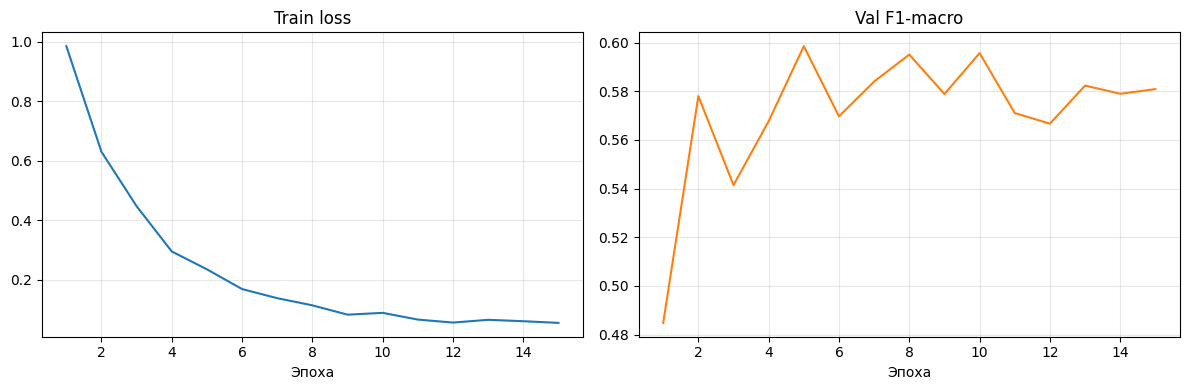

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

hist = pd.DataFrame(history)
axes[0].plot(hist["epoch"], hist["loss"])
axes[0].set_title("Train loss")
axes[0].set_xlabel("Эпоха")
axes[0].grid(alpha=0.3)

axes[1].plot(hist["epoch"], hist["val_f1_macro"], color="tab:orange")
axes[1].set_title("Val F1-macro")
axes[1].set_xlabel("Эпоха")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Подбор порогов

Единый порог 0.5 для всех классов оптимален только если классы сбалансированы —
здесь это не так. Подбираю порог отдельно для каждого класса по F1 на валидации.

Порогов девять, валидация — 58 роликов, так что переобучение под неё вполне
реально. Поэтому смотрю не только на итоговое число, но и на то, насколько
подобранные пороги отличаются от 0.5: сильный сдвиг у редкого класса — скорее
подгонка под несколько примеров, чем найденная закономерность.


In [10]:
val_probs, val_true = predict(val_loader)

grid = np.arange(0.05, 0.96, 0.05)
thresholds = np.full(len(CLASSES), 0.5)

for j in range(len(CLASSES)):
    scores = [f1_score(val_true[:, j], (val_probs[:, j] > t).astype(int), zero_division=0)
              for t in grid]
    thresholds[j] = grid[int(np.argmax(scores))]

val_pred_05 = (val_probs > 0.5).astype(int)
val_pred_tuned = (val_probs > thresholds).astype(int)

print("Порог 0.5      F1-macro:", round(f1_score(val_true, val_pred_05, average="macro", zero_division=0), 4))
print("Подобранные    F1-macro:", round(f1_score(val_true, val_pred_tuned, average="macro", zero_division=0), 4))
print()
print(pd.DataFrame({"threshold": thresholds, "positives_in_val": val_true.sum(axis=0).astype(int)},
                   index=CLASSES).to_string())

Порог 0.5      F1-macro: 0.5986
Подобранные    F1-macro: 0.6876

        threshold  positives_in_val
animal       0.75                 4
car          0.55                 7
cloud        0.50                11
dance        0.30                 3
fire         0.10                 1
flower       0.70                 6
food         0.60                 6
sunset       0.50                 7
water        0.45                16

Подбор порогов даёт **+9 процентных пунктов**: F1-macro 0.599 при едином
пороге 0.5 против 0.688 при подобранных. Для дешёвого шага это много.

Но смотреть надо не только на итог. Пороги разъехались от 0.10 (`fire`) до 0.75
(`animal`), и величина сдвига обратно связана с числом примеров: у `fire` в
валидации ровно один положительный пример, и порог 0.10 подобран именно под
него. Это не найденная закономерность, а подгонка под одно наблюдение — что и
видно ниже по precision этого класса.


## Результаты на валидации


In [11]:
prec, rec, f1, support = precision_recall_fscore_support(
    val_true, val_pred_tuned, average=None, zero_division=0
)

report = pd.DataFrame({
    "precision": prec,
    "recall": rec,
    "f1": f1,
    "average_precision": [average_precision_score(val_true[:, j], val_probs[:, j])
                          if val_true[:, j].sum() > 0 else np.nan
                          for j in range(len(CLASSES))],
    "support": support,
}, index=CLASSES)

print(report.round(3).to_string())
print()
print("F1-macro:      ", round(f1_score(val_true, val_pred_tuned, average="macro", zero_division=0), 4))
print("F1-micro:      ", round(f1_score(val_true, val_pred_tuned, average="micro", zero_division=0), 4))
print("Subset accuracy:", round(float((val_pred_tuned == val_true).all(axis=1).mean()), 4))
print()
print("Для сравнения — доля верно предсказанных ячеек матрицы меток "
      f"(та самая 'class-wise accuracy'): {float((val_pred_tuned == val_true).mean()):.4f}")
print("Константный предсказатель 'нет тега' даёт по ней:",
      round(float((val_true == 0).mean()), 4))

        precision  recall     f1  average_precision  support
animal      1.000   0.750  0.857              0.850        4
car         0.800   0.571  0.667              0.669        7
cloud       0.625   0.909  0.741              0.709       11
dance       0.500   0.667  0.571              0.646        3
fire        0.143   1.000  0.250              0.200        1
flower      1.000   0.833  0.909              0.958        6
food        0.571   0.667  0.615              0.607        6
sunset      0.750   0.857  0.800              0.653        7
water       0.700   0.875  0.778              0.864       16

F1-macro:       0.6876
F1-micro:       0.7206
Subset accuracy: 0.5862

Для сравнения — доля верно предсказанных ячеек матрицы меток (та самая 'class-wise accuracy'): 0.9272
Константный предсказатель 'нет тега' даёт по ней: 0.8831

Последние две строки — главный аргумент против accuracy в этой задаче:
константный предсказатель получает 0.883 против 0.927 у обученной модели.
Разница в 4 пункта, при том что F1-macro у константы равен нулю.

Разброс по классам ожидаемый и объясняется числом примеров, а не «сложностью»
классов. `flower` (AP 0.958) и `animal` (0.850) — визуально однородные сцены с
6 и 4 примерами в валидации. `fire` — precision 0.143 при recall 1.0: модель
находит единственный положительный пример, но вместе с ним шесть ложных. Это
прямое следствие порога 0.10, подобранного под один пример.

`water` с 16 примерами в валидации — самая надёжная оценка в таблице
(F1 0.778, AP 0.864), и именно ей стоит доверять больше остальных.

## Предсказание на тесте


In [12]:
test_probs = predict(test_loader, with_targets=False)
test_pred = (test_probs > thresholds).astype(int)

# если ни один тег не прошёл порог, оставляем самый вероятный:
# формат ответа не допускает пустую строку
empty = test_pred.sum(axis=1) == 0
test_pred[empty, test_probs[empty].argmax(axis=1)] = 1

labels = [", ".join([CLASSES[j] for j in np.where(row)[0]]) for row in test_pred]

submission = pd.read_csv(SAMPLE_SUBMIT)
submission["label"] = labels
submission.to_csv("submission.csv", index=False)

print("Роликов, где ни один тег не прошёл порог:", int(empty.sum()))
print()
print(pd.Series([t for row in labels for t in row.split(", ")]).value_counts().to_string())
submission.head()

Роликов, где ни один тег не прошёл порог: 16

water     150
cloud      91
fire       78
car        65
sunset     56
flower     51
food       51
dance      47
animal     18

,index,file_name,label
0,0,Arizona sunset with creosote bush_preview.mp4,sunset
1,1,_import_616e7f78a17260.13545125_preview.mp4,animal
2,2,200506_Kitchen Food_04_4k_032_preview.mp4,"fire, food"
3,3,Pordeitev_smrek_preview.mp4,"cloud, sunset"
4,4,City street time lapse-H264 75_preview.mp4,"car, water"


## Выводы

**Результат.** F1-macro 0.689, F1-micro 0.721, subset accuracy 0.586 на
отложенной выборке из 58 роликов. Сабмит на Kaggle: 0.911 public, 0.885 private.

**Про метрику соревнования.** Если лидерборд считает ту же долю верных ячеек
матрицы меток, то private-скор 0.885 практически совпадает с константным
предсказателем, который на локальной валидации даёт 0.883. Это не значит, что
модель бесполезна — F1-macro 0.689 против нуля у константы говорит об обратном.
Это значит, что метрика соревнования плохо различает решения, и ориентироваться
на неё при отборе моделей нельзя.

**Разрыв public и private** (0.911 против 0.885) при 435 тестовых роликах —
обычный размер флуктуации на такой выборке, отдельного объяснения не требует.

Ограничения, которые я вижу:

- **290 роликов — очень мало.** Переобучение начинается на пятой эпохе. Редкие
  классы представлены единицами примеров, их метрики шумны, и любая цифра по
  ним имеет широкий доверительный интервал.
- **Пороги подобраны на 58 роликах.** Для `fire` с одним положительным примером
  это заведомая подгонка. Честнее было бы подбирать порог только для классов,
  где в валидации хотя бы 5-10 примеров, а для остальных оставлять 0.5.
- **Порядок кадров теряется.** Average pooling подходит для тегов-сцен (`water`,
  `sunset`), но не для действий (`dance` — F1 0.571, один из худших классов).
- **5 кадров на ролик** — компромисс по скорости; для длинных роликов сцена
  может смениться между кадрами.

Что попробовать дальше: заменить backbone на видеомодель (R(2+1)D, VideoMAE),
которая работает с последовательностью изначально; брать кадры не равномерно, а
по детектору смены сцены; перейти от одного разбиения к кросс-валидации, чтобы
оценки перестали зависеть от конкретного сплита и появилась возможность
подбирать пороги на большем числе примеров.